## Hidden Layers

Using device: cuda

GENERATING DATASET
Read 37001 letters from 'C:\Users\acool\1 Capstone\Engima-Capstone-main\bee movie script.txt'
Training samples:   4000
Validation samples: 1000

CONFIG 1/140 | FC Layers: 1  |  Nodes: 5
Total parameters: 145,049
  Epoch 1/8 | Train Loss: 9.7364 | Val Acc R1:3.9% R2:5.2% R3:0.0% (avg 3.0%)
  Epoch 2/8 | Train Loss: 9.5598 | Val Acc R1:3.9% R2:5.2% R3:0.0% (avg 3.0%)
  Epoch 3/8 | Train Loss: 9.4056 | Val Acc R1:3.9% R2:5.2% R3:0.0% (avg 3.0%)
  Epoch 4/8 | Train Loss: 9.2698 | Val Acc R1:3.9% R2:5.2% R3:0.0% (avg 3.0%)
  Epoch 5/8 | Train Loss: 9.1514 | Val Acc R1:3.9% R2:5.2% R3:0.0% (avg 3.0%)
  Epoch 6/8 | Train Loss: 9.0916 | Val Acc R1:3.9% R2:5.2% R3:0.0% (avg 3.0%)
  Epoch 7/8 | Train Loss: 9.0813 | Val Acc R1:3.9% R2:5.2% R3:0.0% (avg 3.0%)
  Epoch 8/8 | Train Loss: 9.0707 | Val Acc R1:3.9% R2:5.2% R3:0.0% (avg 3.0%)
→ Best avg val accuracy: 3.03%

CONFIG 2/140 | FC Layers: 1  |  Nodes: 13
Total parameters: 170,257
  Epoch 1/8 | Train Loss:

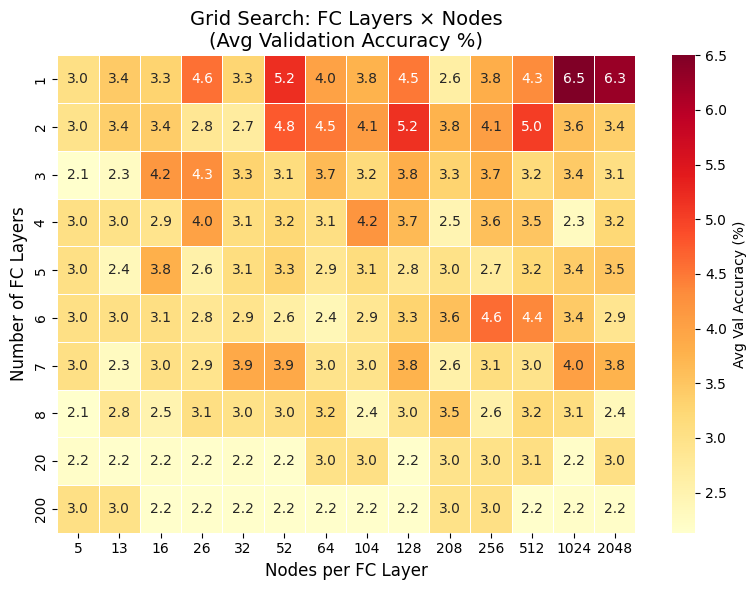


GRID SEARCH COMPLETE


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import string
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Force file paths to be relative to the script location
try:
    BASE_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    BASE_DIR = os.getcwd()

INPUT_TEXT_FILE = os.path.join(BASE_DIR, 'bee movie script.txt')

# Default Enigma configuration
DEFAULT_ROTOR_ORDER = ['III', 'II', 'I']
DEFAULT_POSITIONS   = [0, 0, 0]

# Training configuration
MESSAGE_LENGTH       = 100
NUM_TRAINING_SAMPLES = 5000

# ============================================================================
# GRID SEARCH CONFIGURATION  ← change these lists to expand/narrow the search
# ============================================================================
LAYER_OPTIONS = [1, 2, 3, 4, 5, 6, 7, 8, 20, 200]       # number of FC hidden layers to try
NODE_OPTIONS  = [5, 13, 16, 26, 32, 52, 64, 104, 128, 208, 256, 512, 1024, 2048,]  # number of nodes per FC layer to try
GRID_EPOCHS   = 8               # epochs per configuration (keep low for speed)

# ============================================================================
# ENIGMA SIMULATOR
# ============================================================================
class SimpleEnigma:
    ROTORS = {
        'I':   'EKMFLGDQVZNTOWYHXUSPAIBRCJ',
        'II':  'AJDKSIRUXBLHWTMCQGZNPYFVOE',
        'III': 'BDFHJLCPRTXVZNYEIWGAKMUSQO',
        'IV':  'ESOVPZJAYQUIRHXLNFTGKDCMWB',
        'V':   'VZBRGITYUPSDNHLXAWMJQOFECK',
    }
    NOTCHES   = {'I': 'Q', 'II': 'E', 'III': 'V', 'IV': 'J', 'V': 'Z'}
    REFLECTOR = 'YRUHQSLDPXNGOKMIEBFZCWVJAT'

    def __init__(self, rotors, positions):
        self.rotors           = [self.ROTORS[r] for r in rotors]
        self.rotor_names      = rotors
        self.positions        = positions.copy()
        self.initial_positions = positions.copy()

    def reset(self):
        self.positions = self.initial_positions.copy()

    def set_positions(self, positions):
        self.positions = positions.copy()

    def get_positions(self):
        return self.positions.copy()

    def step_rotors(self):
        if self.rotor_at_notch(1):
            self.positions[1] = (self.positions[1] + 1) % 26
            self.positions[2] = (self.positions[2] + 1) % 26
        elif self.rotor_at_notch(0):
            self.positions[1] = (self.positions[1] + 1) % 26
        self.positions[0] = (self.positions[0] + 1) % 26

    def rotor_at_notch(self, rotor_index):
        notch     = self.NOTCHES[self.rotor_names[rotor_index]]
        notch_pos = ord(notch) - ord('A')
        return self.positions[rotor_index] == notch_pos

    def encrypt_char(self, char):
        if char not in string.ascii_uppercase:
            return char
        self.step_rotors()
        pos = ord(char) - ord('A')
        for i in range(3):
            pos = (pos + self.positions[i]) % 26
            pos = ord(self.rotors[i][pos]) - ord('A')
            pos = (pos - self.positions[i]) % 26
        pos = ord(self.REFLECTOR[pos]) - ord('A')
        for i in range(2, -1, -1):
            pos = (pos + self.positions[i]) % 26
            pos = self.rotors[i].index(chr(pos + ord('A')))
            pos = (pos - self.positions[i]) % 26
        return chr(pos + ord('A'))

    def encrypt(self, text):
        return ''.join(self.encrypt_char(c) for c in text.upper())


# ============================================================================
# DATA PREPARATION
# ============================================================================
def read_text_from_file(filename):
    if not os.path.exists(filename):
        raise FileNotFoundError(f"Input file '{filename}' not found!")
    letters = []
    with open(filename, 'r') as f:
        for line in f:
            for char in line.strip().upper():
                if char in string.ascii_uppercase:
                    letters.append(char)
    text = ''.join(letters)
    print(f"Read {len(text)} letters from '{filename}'")
    return text


def generate_dataset_continuous(filename, rotor_order, initial_positions,
                                 num_samples=5000, message_length=100, step_size=1):
    full_plaintext = read_text_from_file(filename)
    total_needed   = (num_samples * step_size) + message_length
    if len(full_plaintext) < total_needed:
        repeats        = (total_needed // len(full_plaintext)) + 1
        full_plaintext = full_plaintext * repeats

    enigma           = SimpleEnigma(rotor_order, initial_positions)
    full_ciphertext  = enigma.encrypt(full_plaintext)
    enigma.set_positions(initial_positions)

    data = []
    for i in range(num_samples):
        start_idx      = i * step_size
        plaintext      = full_plaintext[start_idx : start_idx + message_length]
        ciphertext     = full_ciphertext[start_idx : start_idx + message_length]
        chunk_positions = enigma.get_positions()
        for char in full_plaintext[start_idx : start_idx + step_size]:
            if char in string.ascii_uppercase:
                enigma.step_rotors()
        data.append({
            'ciphertext': ciphertext,
            'plaintext':  plaintext,
            'rotors':     rotor_order,
            'positions':  chunk_positions,
        })
    return data


# ============================================================================
# PYTORCH DATASET
# ============================================================================
class EnigmaDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item             = self.data[idx]
        ciphertext_enc   = self.encode_text(item['ciphertext'])
        positions        = torch.tensor(item['positions'], dtype=torch.long)
        return ciphertext_enc, positions

    @staticmethod
    def encode_text(text):
        encoded = torch.zeros(len(text), 26)
        for i, char in enumerate(text):
            if char in string.ascii_uppercase:
                encoded[i, ord(char) - ord('A')] = 1
        return encoded


# ============================================================================
# NEURAL NETWORK  (parametric layers & nodes)
# ============================================================================
class EnigmaRotorClassifier(nn.Module):
    """
    CNN backbone + configurable FC head.

    Parameters
    ----------
    message_length : int   – length of input ciphertext
    hidden_dim     : int   – nodes per FC hidden layer     ← NODE loop variable
    num_fc_layers  : int   – number of FC hidden layers   ← LAYER loop variable
    """

    def __init__(self, message_length=100, hidden_dim=256, num_fc_layers=2):
        super().__init__()

        # --- Fixed CNN backbone (3 conv layers) ---
        self.conv1      = nn.Conv1d(26,  64,  kernel_size=3, padding=1)
        self.conv2      = nn.Conv1d(64,  128, kernel_size=3, padding=1)
        self.conv3      = nn.Conv1d(128, 256, kernel_size=3, padding=1)
        self.pool       = nn.MaxPool1d(2)
        self.dropout    = nn.Dropout(0.3)
        self.bn1        = nn.BatchNorm1d(64)
        self.bn2        = nn.BatchNorm1d(128)
        self.bn3        = nn.BatchNorm1d(256)
        self.relu       = nn.ReLU()
        conv_output_size = (message_length // 8) * 256   # after 3 pools

        # --- Dynamic FC hidden layers ---
        # Build a list: [conv_output -> hidden_dim, hidden_dim -> hidden_dim, ...]
        fc_layers   = []
        in_features = conv_output_size
        for _ in range(num_fc_layers):
            fc_layers.append(nn.Linear(in_features, hidden_dim))
            fc_layers.append(nn.ReLU())
            fc_layers.append(nn.Dropout(0.3))
            in_features = hidden_dim
        self.fc_hidden = nn.Sequential(*fc_layers)

        # --- Output heads (one per rotor) ---
        self.rotor1_head = nn.Linear(in_features, 26)
        self.rotor2_head = nn.Linear(in_features, 26)
        self.rotor3_head = nn.Linear(in_features, 26)

    def forward(self, x):
        x = x.transpose(1, 2)                                     # (B, 26, L)
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.fc_hidden(x)
        return self.rotor1_head(x), self.rotor2_head(x), self.rotor3_head(x)


# ============================================================================
# TRAINING
# ============================================================================
def train_model(model, train_loader, val_loader, num_epochs=8, device='cpu'):
    model     = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3)
    best_val_acc = 0.0

    for epoch in range(num_epochs):
        # ---- Training ----
        model.train()
        train_correct = [0, 0, 0]
        train_total   = 0
        train_loss    = 0.0

        for ciphertext, positions in train_loader:
            ciphertext = ciphertext.to(device)
            positions  = positions.to(device)
            optimizer.zero_grad()
            o1, o2, o3 = model(ciphertext)
            loss = (criterion(o1, positions[:, 0])
                  + criterion(o2, positions[:, 1])
                  + criterion(o3, positions[:, 2]))
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            for k, out in enumerate([o1, o2, o3]):
                train_correct[k] += (out.argmax(1) == positions[:, k]).sum().item()
            train_total += positions.size(0)

        # ---- Validation ----
        model.eval()
        val_correct = [0, 0, 0]
        val_total   = 0
        val_loss    = 0.0

        with torch.no_grad():
            for ciphertext, positions in val_loader:
                ciphertext = ciphertext.to(device)
                positions  = positions.to(device)
                o1, o2, o3 = model(ciphertext)
                loss = (criterion(o1, positions[:, 0])
                      + criterion(o2, positions[:, 1])
                      + criterion(o3, positions[:, 2]))
                val_loss += loss.item()
                for k, out in enumerate([o1, o2, o3]):
                    val_correct[k] += (out.argmax(1) == positions[:, k]).sum().item()
                val_total += positions.size(0)

        train_acc = [(c / train_total) * 100 for c in train_correct]
        val_acc   = [(c / val_total)   * 100 for c in val_correct]
        avg_val   = sum(val_acc) / 3
        scheduler.step(val_loss)

        print(f'  Epoch {epoch+1}/{num_epochs} | '
              f'Train Loss: {train_loss/len(train_loader):.4f} | '
              f'Val Acc R1:{val_acc[0]:.1f}% R2:{val_acc[1]:.1f}% R3:{val_acc[2]:.1f}% '
              f'(avg {avg_val:.1f}%)')

        if avg_val > best_val_acc:
            best_val_acc = avg_val
            torch.save(model.state_dict(), 'best_enigma_model.pth')

    return best_val_acc


# ============================================================================
# HEATMAP
# ============================================================================
def plot_heatmap(results, layer_options, node_options):
    """
    results : dict  {(num_layers, num_nodes): avg_val_accuracy}
    Saves heatmap as 'grid_search_heatmap.png'
    """
    grid = np.zeros((len(layer_options), len(node_options)))
    for i, layers in enumerate(layer_options):
        for j, nodes in enumerate(node_options):
            grid[i, j] = results.get((layers, nodes), 0.0)

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        grid,
        annot=True,
        fmt='.1f',
        xticklabels=node_options,
        yticklabels=layer_options,
        cmap='YlOrRd',
        linewidths=0.5,
        ax=ax,
        cbar_kws={'label': 'Avg Val Accuracy (%)'},
    )
    ax.set_xlabel('Nodes per FC Layer', fontsize=12)
    ax.set_ylabel('Number of FC Layers', fontsize=12)
    ax.set_title('Grid Search: FC Layers × Nodes\n(Avg Validation Accuracy %)', fontsize=14)
    plt.tight_layout()
    plt.savefig('grid_search_heatmap.png', dpi=150)
    print('\n✓ Heatmap saved as grid_search_heatmap.png')
    plt.show()


# ============================================================================
# MAIN
# ============================================================================
if __name__ == '__main__':
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Using device: {device}\n')

    # ---- Generate dataset once (shared across all configurations) ----
    print('=' * 60)
    print('GENERATING DATASET')
    print('=' * 60)

    try:
        dataset = generate_dataset_continuous(
            filename=INPUT_TEXT_FILE,
            rotor_order=DEFAULT_ROTOR_ORDER,
            initial_positions=DEFAULT_POSITIONS,
            num_samples=NUM_TRAINING_SAMPLES,
            message_length=MESSAGE_LENGTH,
            step_size=1,
        )
    except FileNotFoundError as e:
        raise FileNotFoundError(
            f"Required input file '{INPUT_TEXT_FILE}' not found. Please create it first."
        ) from e

    split_idx     = int(0.8 * len(dataset))
    train_dataset = EnigmaDataset(dataset[:split_idx])
    val_dataset   = EnigmaDataset(dataset[split_idx:])
    train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=0)
    val_loader    = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=0)

    print(f'Training samples:   {len(train_dataset)}')
    print(f'Validation samples: {len(val_dataset)}')

    # ---- Grid search ----
    results = {}   # {(num_layers, num_nodes): best_avg_val_acc}

    total_configs = len(LAYER_OPTIONS) * len(NODE_OPTIONS)
    config_num    = 0

    # Outer loop: number of FC hidden layers
    for num_layers in LAYER_OPTIONS:

        # Inner loop: number of nodes per FC layer
        for num_nodes in NODE_OPTIONS:
            config_num += 1
            print('\n' + '=' * 60)
            print(f'CONFIG {config_num}/{total_configs} | '
                  f'FC Layers: {num_layers}  |  Nodes: {num_nodes}')
            print('=' * 60)

            model = EnigmaRotorClassifier(
                message_length=MESSAGE_LENGTH,
                hidden_dim=num_nodes,
                num_fc_layers=num_layers,
            )
            total_params = sum(p.numel() for p in model.parameters())
            print(f'Total parameters: {total_params:,}')

            best_acc = train_model(
                model, train_loader, val_loader,
                num_epochs=GRID_EPOCHS,
                device=device,
            )
            results[(num_layers, num_nodes)] = best_acc
            print(f'→ Best avg val accuracy: {best_acc:.2f}%')

    # ---- Summary table ----
    print('\n' + '=' * 60)
    print('GRID SEARCH RESULTS SUMMARY')
    print('=' * 60)
    print(f'{"Layers":>8}  {"Nodes":>6}  {"Val Acc (%)":>12}')
    print('-' * 32)
    for (layers, nodes), acc in sorted(results.items()):
        print(f'{layers:>8}  {nodes:>6}  {acc:>12.2f}')

    best_key = max(results, key=results.get)
    print(f'\n✓ Best configuration: {best_key[0]} layers, {best_key[1]} nodes '
          f'→ {results[best_key]:.2f}% accuracy')

    # ---- Heatmap ----
    plot_heatmap(results, LAYER_OPTIONS, NODE_OPTIONS)

    print('\n' + '=' * 60)
    print('GRID SEARCH COMPLETE')
    print('=' * 60)

## Convolution Layers

Using device: cuda

GENERATING DATASET
Read 37001 letters from 'C:\Users\acool\1 Capstone\Engima-Capstone-main\bee movie script.txt'
Training samples:   4000
Validation samples: 1000

CONFIG 1/18 | Conv Layers: 1  |  Base Channels: 128
  Channel progression: 26 (input) → 128
Total parameters: 1,734,862
  Epoch 1/5 | Train Loss: 8.6548 | Val Acc R1:3.9% R2:2.5% R3:0.0% (avg 2.1%)
  Epoch 2/5 | Train Loss: 8.3305 | Val Acc R1:3.6% R2:6.4% R3:0.0% (avg 3.3%)
  Epoch 3/5 | Train Loss: 7.8806 | Val Acc R1:3.8% R2:7.2% R3:0.1% (avg 3.7%)
  Epoch 4/5 | Train Loss: 7.5657 | Val Acc R1:3.9% R2:3.2% R3:0.1% (avg 2.4%)
  Epoch 5/5 | Train Loss: 7.3567 | Val Acc R1:3.5% R2:4.8% R3:0.0% (avg 2.8%)
→ Best avg val accuracy: 3.70%

CONFIG 2/18 | Conv Layers: 1  |  Base Channels: 256
  Channel progression: 26 (input) → 256
Total parameters: 3,383,630
  Epoch 1/5 | Train Loss: 8.7116 | Val Acc R1:3.3% R2:2.6% R3:0.0% (avg 2.0%)
  Epoch 2/5 | Train Loss: 8.3741 | Val Acc R1:4.6% R2:9.5% R3:0.0% (avg 4.7%

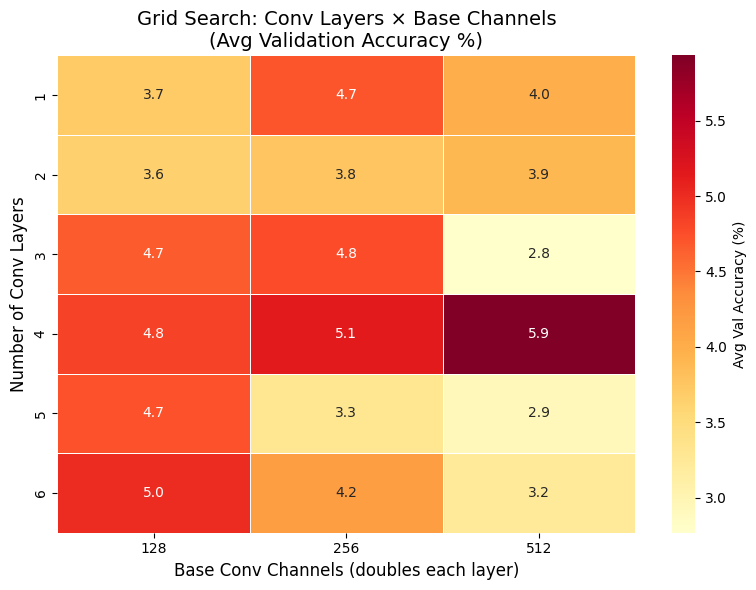


GRID SEARCH COMPLETE


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import string
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Force file paths to be relative to the script location
try:
    BASE_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    BASE_DIR = os.getcwd()

INPUT_TEXT_FILE = os.path.join(BASE_DIR, 'bee movie script.txt')

# Default Enigma configuration
DEFAULT_ROTOR_ORDER = ['III', 'II', 'I']
DEFAULT_POSITIONS   = [0, 0, 0]

# Training configuration
MESSAGE_LENGTH       = 100
NUM_TRAINING_SAMPLES = 5000

# ============================================================================
# GRID SEARCH CONFIGURATION  ← change these lists to expand/narrow the search
# ============================================================================
CONV_LAYER_OPTIONS = [1, 2, 3, 4, 5, 6]       # number of conv layers to try
CONV_NODE_OPTIONS  = [128, 256, 512]   # base channel size for conv layers to try
GRID_EPOCHS        = 5               # epochs per configuration (keep low for speed)

# ============================================================================
# ENIGMA SIMULATOR
# ============================================================================
class SimpleEnigma:
    ROTORS = {
        'I':   'EKMFLGDQVZNTOWYHXUSPAIBRCJ',
        'II':  'AJDKSIRUXBLHWTMCQGZNPYFVOE',
        'III': 'BDFHJLCPRTXVZNYEIWGAKMUSQO',
        'IV':  'ESOVPZJAYQUIRHXLNFTGKDCMWB',
        'V':   'VZBRGITYUPSDNHLXAWMJQOFECK',
    }
    NOTCHES   = {'I': 'Q', 'II': 'E', 'III': 'V', 'IV': 'J', 'V': 'Z'}
    REFLECTOR = 'YRUHQSLDPXNGOKMIEBFZCWVJAT'

    def __init__(self, rotors, positions):
        self.rotors           = [self.ROTORS[r] for r in rotors]
        self.rotor_names      = rotors
        self.positions        = positions.copy()
        self.initial_positions = positions.copy()

    def reset(self):
        self.positions = self.initial_positions.copy()

    def set_positions(self, positions):
        self.positions = positions.copy()

    def get_positions(self):
        return self.positions.copy()

    def step_rotors(self):
        if self.rotor_at_notch(1):
            self.positions[1] = (self.positions[1] + 1) % 26
            self.positions[2] = (self.positions[2] + 1) % 26
        elif self.rotor_at_notch(0):
            self.positions[1] = (self.positions[1] + 1) % 26
        self.positions[0] = (self.positions[0] + 1) % 26

    def rotor_at_notch(self, rotor_index):
        notch     = self.NOTCHES[self.rotor_names[rotor_index]]
        notch_pos = ord(notch) - ord('A')
        return self.positions[rotor_index] == notch_pos

    def encrypt_char(self, char):
        if char not in string.ascii_uppercase:
            return char
        self.step_rotors()
        pos = ord(char) - ord('A')
        for i in range(3):
            pos = (pos + self.positions[i]) % 26
            pos = ord(self.rotors[i][pos]) - ord('A')
            pos = (pos - self.positions[i]) % 26
        pos = ord(self.REFLECTOR[pos]) - ord('A')
        for i in range(2, -1, -1):
            pos = (pos + self.positions[i]) % 26
            pos = self.rotors[i].index(chr(pos + ord('A')))
            pos = (pos - self.positions[i]) % 26
        return chr(pos + ord('A'))

    def encrypt(self, text):
        return ''.join(self.encrypt_char(c) for c in text.upper())


# ============================================================================
# DATA PREPARATION
# ============================================================================
def read_text_from_file(filename):
    if not os.path.exists(filename):
        raise FileNotFoundError(f"Input file '{filename}' not found!")
    letters = []
    with open(filename, 'r') as f:
        for line in f:
            for char in line.strip().upper():
                if char in string.ascii_uppercase:
                    letters.append(char)
    text = ''.join(letters)
    print(f"Read {len(text)} letters from '{filename}'")
    return text


def generate_dataset_continuous(filename, rotor_order, initial_positions,
                                 num_samples=5000, message_length=100, step_size=1):
    full_plaintext = read_text_from_file(filename)
    total_needed   = (num_samples * step_size) + message_length
    if len(full_plaintext) < total_needed:
        repeats        = (total_needed // len(full_plaintext)) + 1
        full_plaintext = full_plaintext * repeats

    enigma           = SimpleEnigma(rotor_order, initial_positions)
    full_ciphertext  = enigma.encrypt(full_plaintext)
    enigma.set_positions(initial_positions)

    data = []
    for i in range(num_samples):
        start_idx      = i * step_size
        plaintext      = full_plaintext[start_idx : start_idx + message_length]
        ciphertext     = full_ciphertext[start_idx : start_idx + message_length]
        chunk_positions = enigma.get_positions()
        for char in full_plaintext[start_idx : start_idx + step_size]:
            if char in string.ascii_uppercase:
                enigma.step_rotors()
        data.append({
            'ciphertext': ciphertext,
            'plaintext':  plaintext,
            'rotors':     rotor_order,
            'positions':  chunk_positions,
        })
    return data


# ============================================================================
# PYTORCH DATASET
# ============================================================================
class EnigmaDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item             = self.data[idx]
        ciphertext_enc   = self.encode_text(item['ciphertext'])
        positions        = torch.tensor(item['positions'], dtype=torch.long)
        return ciphertext_enc, positions

    @staticmethod
    def encode_text(text):
        encoded = torch.zeros(len(text), 26)
        for i, char in enumerate(text):
            if char in string.ascii_uppercase:
                encoded[i, ord(char) - ord('A')] = 1
        return encoded


# ============================================================================
# NEURAL NETWORK  (parametric conv layers & nodes)
# ============================================================================
class EnigmaRotorClassifier(nn.Module):
    """
    Fully dynamic CNN + fixed FC head.

    Parameters
    ----------
    message_length  : int – length of input ciphertext
    base_channels   : int – channel count of the first conv layer; each
                            subsequent layer doubles this value
                            e.g. base_channels=32  →  32, 64, 128, ...
                            ← CONV NODE loop variable
    num_conv_layers : int – how many conv+pool blocks to stack
                            ← CONV LAYER loop variable
    fc_hidden_dim   : int – fixed size of the two FC hidden layers
    """

    def __init__(self, message_length=100, base_channels=64,
                 num_conv_layers=3, fc_hidden_dim=256):
        super().__init__()

        self.pool    = nn.MaxPool1d(2)
        self.dropout = nn.Dropout(0.3)
        self.relu    = nn.ReLU()

        # --- Dynamic conv blocks ---
        # channels grow as: base, base*2, base*4, ...
        conv_blocks = []
        in_ch = 26  # input has 26 channels (one-hot alphabet)
        for i in range(num_conv_layers):
            out_ch = base_channels * (2 ** i)
            conv_blocks.append(nn.Conv1d(in_ch, out_ch, kernel_size=3, padding=1))
            conv_blocks.append(nn.BatchNorm1d(out_ch))
            conv_blocks.append(nn.ReLU())
            # MaxPool is applied manually in forward so we know the output size
            in_ch = out_ch
        self.conv_blocks = nn.ModuleList(
            [nn.Sequential(
                nn.Conv1d(
                    26 if i == 0 else base_channels * (2 ** (i - 1)),
                    base_channels * (2 ** i),
                    kernel_size=3, padding=1
                ),
                nn.BatchNorm1d(base_channels * (2 ** i)),
                nn.ReLU(),
            ) for i in range(num_conv_layers)]
        )
        final_channels = base_channels * (2 ** (num_conv_layers - 1))

        # Simulate the exact sequence length after forward() to get correct flat size.
        # Pool is only applied when seq_len >= 2, matching forward() behavior.
        seq_len = message_length
        for _ in range(num_conv_layers):
            if seq_len >= 2:
                seq_len = seq_len // 2
        conv_output_size = seq_len * final_channels

        # --- Fixed FC head (2 hidden layers) ---
        self.fc_hidden = nn.Sequential(
            nn.Linear(conv_output_size, fc_hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(fc_hidden_dim, fc_hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
        )

        # --- Output heads (one per rotor) ---
        self.rotor1_head = nn.Linear(fc_hidden_dim, 26)
        self.rotor2_head = nn.Linear(fc_hidden_dim, 26)
        self.rotor3_head = nn.Linear(fc_hidden_dim, 26)

    def forward(self, x):
        x = x.transpose(1, 2)          # (B, 26, L)
        for block in self.conv_blocks:
            x = block(x)               # conv + BN + ReLU
            if x.size(2) >= 2:         # only pool if sequence is long enough
                x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.fc_hidden(x)
        return self.rotor1_head(x), self.rotor2_head(x), self.rotor3_head(x)


# ============================================================================
# TRAINING
# ============================================================================
def train_model(model, train_loader, val_loader, num_epochs=8, device='cpu'):
    model     = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3)
    best_val_acc = 0.0

    for epoch in range(num_epochs):
        # ---- Training ----
        model.train()
        train_correct = [0, 0, 0]
        train_total   = 0
        train_loss    = 0.0

        for ciphertext, positions in train_loader:
            ciphertext = ciphertext.to(device)
            positions  = positions.to(device)
            optimizer.zero_grad()
            o1, o2, o3 = model(ciphertext)
            loss = (criterion(o1, positions[:, 0])
                  + criterion(o2, positions[:, 1])
                  + criterion(o3, positions[:, 2]))
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            for k, out in enumerate([o1, o2, o3]):
                train_correct[k] += (out.argmax(1) == positions[:, k]).sum().item()
            train_total += positions.size(0)

        # ---- Validation ----
        model.eval()
        val_correct = [0, 0, 0]
        val_total   = 0
        val_loss    = 0.0

        with torch.no_grad():
            for ciphertext, positions in val_loader:
                ciphertext = ciphertext.to(device)
                positions  = positions.to(device)
                o1, o2, o3 = model(ciphertext)
                loss = (criterion(o1, positions[:, 0])
                      + criterion(o2, positions[:, 1])
                      + criterion(o3, positions[:, 2]))
                val_loss += loss.item()
                for k, out in enumerate([o1, o2, o3]):
                    val_correct[k] += (out.argmax(1) == positions[:, k]).sum().item()
                val_total += positions.size(0)

        train_acc = [(c / train_total) * 100 for c in train_correct]
        val_acc   = [(c / val_total)   * 100 for c in val_correct]
        avg_val   = sum(val_acc) / 3
        scheduler.step(val_loss)

        print(f'  Epoch {epoch+1}/{num_epochs} | '
              f'Train Loss: {train_loss/len(train_loader):.4f} | '
              f'Val Acc R1:{val_acc[0]:.1f}% R2:{val_acc[1]:.1f}% R3:{val_acc[2]:.1f}% '
              f'(avg {avg_val:.1f}%)')

        if avg_val > best_val_acc:
            best_val_acc = avg_val
            torch.save(model.state_dict(), 'best_enigma_model.pth')

    return best_val_acc


# ============================================================================
# HEATMAP
# ============================================================================
def plot_heatmap(results, layer_options, node_options):
    """
    results : dict  {(num_conv_layers, base_channels): avg_val_accuracy}
    Saves heatmap as 'grid_search_heatmap.png'
    """
    grid = np.zeros((len(layer_options), len(node_options)))
    for i, layers in enumerate(layer_options):
        for j, nodes in enumerate(node_options):
            grid[i, j] = results.get((layers, nodes), 0.0)

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        grid,
        annot=True,
        fmt='.1f',
        xticklabels=node_options,
        yticklabels=layer_options,
        cmap='YlOrRd',
        linewidths=0.5,
        ax=ax,
        cbar_kws={'label': 'Avg Val Accuracy (%)'},
    )
    ax.set_xlabel('Base Conv Channels (doubles each layer)', fontsize=12)
    ax.set_ylabel('Number of Conv Layers', fontsize=12)
    ax.set_title('Grid Search: Conv Layers × Base Channels\n(Avg Validation Accuracy %)', fontsize=14)
    plt.tight_layout()
    plt.savefig('grid_search_heatmap.png', dpi=150)
    print('\n✓ Heatmap saved as grid_search_heatmap.png')
    plt.show()


# ============================================================================
# MAIN
# ============================================================================
if __name__ == '__main__':
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Using device: {device}\n')

    # ---- Generate dataset once (shared across all configurations) ----
    print('=' * 60)
    print('GENERATING DATASET')
    print('=' * 60)

    try:
        dataset = generate_dataset_continuous(
            filename=INPUT_TEXT_FILE,
            rotor_order=DEFAULT_ROTOR_ORDER,
            initial_positions=DEFAULT_POSITIONS,
            num_samples=NUM_TRAINING_SAMPLES,
            message_length=MESSAGE_LENGTH,
            step_size=1,
        )
    except FileNotFoundError as e:
        raise FileNotFoundError(
            f"Required input file '{INPUT_TEXT_FILE}' not found. Please create it first."
        ) from e

    split_idx     = int(0.8 * len(dataset))
    train_dataset = EnigmaDataset(dataset[:split_idx])
    val_dataset   = EnigmaDataset(dataset[split_idx:])
    train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=0)
    val_loader    = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=0)

    print(f'Training samples:   {len(train_dataset)}')
    print(f'Validation samples: {len(val_dataset)}')

    # ---- Grid search ----
    results = {}   # {(num_conv_layers, base_channels): best_avg_val_acc}

    total_configs = len(CONV_LAYER_OPTIONS) * len(CONV_NODE_OPTIONS)
    config_num    = 0

    # Outer loop: number of conv layers
    for num_conv_layers in CONV_LAYER_OPTIONS:

        # Inner loop: base channel size (nodes) for conv layers
        for base_channels in CONV_NODE_OPTIONS:
            config_num += 1
            print('\n' + '=' * 60)
            print(f'CONFIG {config_num}/{total_configs} | '
                  f'Conv Layers: {num_conv_layers}  |  Base Channels: {base_channels}')
            # Show the actual channel progression for this config
            channel_sizes = [base_channels * (2 ** i) for i in range(num_conv_layers)]
            print(f'  Channel progression: 26 (input) → {" → ".join(map(str, channel_sizes))}')
            print('=' * 60)

            model = EnigmaRotorClassifier(
                message_length=MESSAGE_LENGTH,
                base_channels=base_channels,
                num_conv_layers=num_conv_layers,
            )
            total_params = sum(p.numel() for p in model.parameters())
            print(f'Total parameters: {total_params:,}')

            best_acc = train_model(
                model, train_loader, val_loader,
                num_epochs=GRID_EPOCHS,
                device=device,
            )
            results[(num_conv_layers, base_channels)] = best_acc
            print(f'→ Best avg val accuracy: {best_acc:.2f}%')

    # ---- Summary table ----
    print('\n' + '=' * 60)
    print('GRID SEARCH RESULTS SUMMARY')
    print('=' * 60)
    print(f'{"Conv Layers":>12}  {"Base Ch":>8}  {"Val Acc (%)":>12}')
    print('-' * 38)
    for (layers, channels), acc in sorted(results.items()):
        print(f'{layers:>12}  {channels:>8}  {acc:>12.2f}')

    best_key = max(results, key=results.get)
    print(f'\n✓ Best configuration: {best_key[0]} conv layers, {best_key[1]} base channels '
          f'→ {results[best_key]:.2f}% accuracy')

    # ---- Heatmap ----
    plot_heatmap(results, CONV_LAYER_OPTIONS, CONV_NODE_OPTIONS)

    print('\n' + '=' * 60)
    print('GRID SEARCH COMPLETE')
    print('=' * 60)